# Customer Churn Prediction using Logistic Regression

## Assignment – 2

### Submitted By

**Name:** SOUMYODYUTI RAY

**Registration Number:** 23BCE11818

**Application Number:** IN26011258

### Objective

The objective of this assignment is to develop a Logistic Regression model to predict whether a customer is likely to leave (churn) based on demographic information and telecommunication service usage. The assignment includes data understanding, preprocessing, model development, model evaluation, and interpretation of results.

# Step 1: Import Required Libraries

In this step, we import all the Python libraries required for data analysis, preprocessing, model development, evaluation, and visualization.

In [1]:
# Importing libraries for data manipulation
import pandas as pd
import numpy as np

# Importing libraries for visualization
import matplotlib.pyplot as plt

# Importing preprocessing tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Importing Logistic Regression model
from sklearn.linear_model import LogisticRegression

# Importing evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Step 2: Load the Dataset

In this step, we load the Telco Customer Churn dataset using the Pandas library. After loading the dataset, we display the first five records to understand its structure and verify that it has been loaded correctly.

In [2]:
# Loading the dataset

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Displaying the first five rows

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Dataset Dimensions

The shape of the dataset provides information about the number of rows (observations) and columns (features) present in the dataset.

In [3]:
# Display the number of rows and columns

print("Dataset Shape:", df.shape)

Dataset Shape: (7043, 21)


## Dataset Columns

The following code displays the names of all the features available in the dataset.

In [4]:
# Display all column names

print("Columns in the dataset:")

for column in df.columns:
    print(column)

Columns in the dataset:
customerID
gender
SeniorCitizen
Partner
Dependents
tenure
PhoneService
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaperlessBilling
PaymentMethod
MonthlyCharges
TotalCharges
Churn


## Dataset Information

The dataset information provides details about the number of entries, column names, data types, and the number of non-null values in each column. This helps us understand the structure of the dataset and identify any missing values.

In [5]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Summary Statistics

The summary statistics provide useful information about the numerical features in the dataset, including the count, mean, standard deviation, minimum value, maximum value, and quartiles.

In [6]:
# Display summary statistics for numerical features

df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Identifying Feature Types

The dataset contains both numerical and categorical features. The target variable is the customer churn status (`Churn`), which the Logistic Regression model will predict.

In [7]:
# Identifying numerical and categorical features

numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

# Display the features

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

print("\nTarget Variable:")
print("Churn")

Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges']

Categorical Features:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']

Target Variable:
Churn


## Observations

- The dataset contains **21 columns**, including the target variable (`Churn`).
- The dataset includes both numerical and categorical features.
- The target variable for prediction is **Churn**.
- The `customerID` column is a unique identifier and will not contribute to predicting customer churn.
- The `TotalCharges` column is currently stored as an object data type and will be converted to a numerical format during data preprocessing.

# Step 3: Data Preprocessing

Data preprocessing is an important step in machine learning. It involves preparing the dataset for model training by handling missing values, converting categorical variables into numerical form, and splitting the dataset into training and testing sets.

## Checking for Missing Values

Before training the Logistic Regression model, it is important to check whether the dataset contains any missing values. Missing values can negatively affect the performance of the model and should be handled appropriately.

In [8]:
# Checking for missing values in each column

print("Missing Values in Each Column:")
print(df.isnull().sum())

Missing Values in Each Column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


## Converting the TotalCharges Column

The `TotalCharges` column is stored as an object (text) data type in the dataset. Since it represents numerical values, it must be converted into a numeric format. Any invalid or blank entries will be converted into missing values (NaN).

In [9]:
# Converting TotalCharges to numeric

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

## Handling Missing Values

After converting the `TotalCharges` column to numeric, any blank entries become missing values (NaN). These missing values are replaced with the median value of the column to preserve the dataset while minimizing the effect of outliers.

In [10]:
# Filling missing values with the median

df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

# Verify that no missing values remain

print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


## Removing the Customer ID Column

The `customerID` column is a unique identifier assigned to each customer. Since it does not contain useful information for predicting customer churn, it is removed before model training.

In [11]:
# Dropping the customerID column

df.drop("customerID", axis=1, inplace=True)

## Encoding Categorical Variables

Machine learning algorithms require numerical input. Therefore, all categorical variables are converted into numerical values using Label Encoding.

In [12]:
# Creating a LabelEncoder object

label_encoder = LabelEncoder()

# Encoding all categorical columns

categorical_columns = df.select_dtypes(include=["object"]).columns

for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column])

# Display the first five rows after encoding

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


## Splitting Features and Target Variable

The dataset is divided into:

- **Features (X):** Independent variables used to predict customer churn.
- **Target Variable (y):** Customer churn (`Churn`).

In [13]:
# Splitting the dataset into features and target variable

X = df.drop("Churn", axis=1)
y = df["Churn"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (7043, 19)
Target Shape: (7043,)


## Splitting the Dataset into Training and Testing Sets

The dataset is divided into:

- **80% Training Data**
- **20% Testing Data**

The training data is used to train the Logistic Regression model, while the testing data is used to evaluate its performance.

In [14]:
# Splitting the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (5634, 19)
Testing Features: (1409, 19)
Training Target: (5634,)
Testing Target: (1409,)


# Step 4: Model Development

In this step, we build a **Logistic Regression** model using the training dataset. The model learns the relationship between the customer attributes and the target variable (`Churn`).

After training the model, it is used to predict customer churn for the test dataset.


## Creating and Training the Logistic Regression Model

The `LogisticRegression` model from the Scikit-learn library is used to train the model using the training dataset.

In [16]:
# Creating the Logistic Regression model

model = LogisticRegression(max_iter=10000)

# Training the model

model.fit(X_train, y_train)

print("Model training completed successfully.")

Model training completed successfully.


## Model Coefficients

The coefficients indicate the influence of each feature on the prediction of customer churn. Positive coefficients increase the likelihood of churn, while negative coefficients decrease it.

In [17]:
# Displaying model coefficients

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients

,Feature,Coefficient
0,gender,-0.050988
1,SeniorCitizen,0.179930
2,Partner,0.068688
3,Dependents,-0.182388
4,tenure,-0.055201
5,PhoneService,-1.024669
6,MultipleLines,0.070978
7,InternetService,0.229412
8,OnlineSecurity,-0.292631
9,OnlineBackup,-0.155488


## Model Intercept

The intercept represents the baseline prediction of the Logistic Regression model when all the independent variables are equal to zero.

In [19]:
# Displaying the intercept

print("Intercept:", model.intercept_[0])

Intercept: -0.48571697298915245


## Predicting Customer Churn

After training the Logistic Regression model, predictions are made on the test dataset. These predictions will be compared with the actual customer churn values during model evaluation.

In [20]:
# Predicting customer churn for the test dataset

y_pred = model.predict(X_test)

## Comparing Actual and Predicted Values

The following table compares the actual customer churn values with the values predicted by the Logistic Regression model for the first few test samples.

In [21]:
# Creating a comparison table

comparison = pd.DataFrame({
    "Actual Churn": y_test.values,
    "Predicted Churn": y_pred
})

comparison.head(10)

,Actual Churn,Predicted Churn
0,1,1
1,0,0
2,0,0
3,1,1
4,0,0
5,1,0
6,0,0
7,0,0
8,1,0
9,1,0


# Step 5: Model Evaluation

Model evaluation helps determine how well the Logistic Regression model predicts customer churn. In this assignment, the following evaluation metrics are used:

- **Accuracy Score:** Measures the overall proportion of correctly classified instances.
- **Precision:** Measures the proportion of correctly predicted positive cases out of all predicted positive cases.
- **Recall:** Measures the proportion of actual positive cases that are correctly identified.
- **F1-Score:** Represents the harmonic mean of Precision and Recall, providing a balanced evaluation of the model.

In [22]:
# Calculating evaluation metrics

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy Score :", accuracy)
print("Precision      :", precision)
print("Recall         :", recall)
print("F1-Score       :", f1)

Accuracy Score : 0.8168914123491838
Precision      : 0.6802507836990596
Recall         : 0.5817694369973191
F1-Score       : 0.6271676300578035


## Confusion Matrix

A confusion matrix summarizes the classification results by comparing the actual customer churn values with the predicted values. It provides insight into the number of correct and incorrect predictions made by the model.

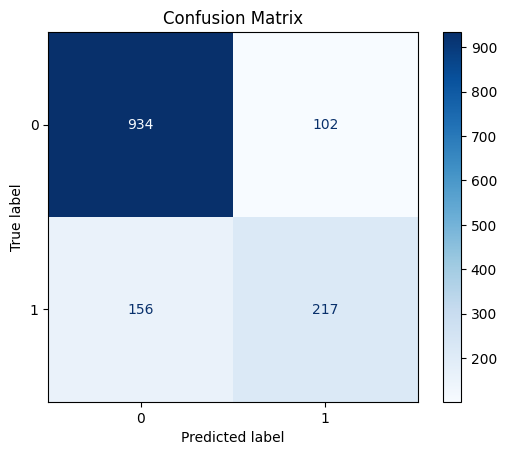

In [23]:
# Generating the confusion matrix

cm = confusion_matrix(y_test, y_pred)

# Displaying the confusion matrix

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

## Observations

1. The Logistic Regression model achieved a good accuracy score, indicating that it correctly classified a large proportion of customers.

2. The precision and recall scores indicate that the model is reasonably effective at identifying customers who are likely to churn, although some churn cases are still misclassified.

3. The confusion matrix shows that the model predicts non-churn customers more accurately than churn customers, suggesting that additional feature engineering or more advanced classification models may further improve prediction performance.

# Step 6: Conclusion

The Logistic Regression model was successfully developed to predict customer churn using demographic and telecommunication service-related features. The model demonstrated satisfactory performance, achieving good classification accuracy while effectively identifying patterns associated with customer churn. Features such as contract type, tenure, monthly charges, and total charges were found to influence the likelihood of a customer leaving the service. The evaluation metrics and confusion matrix indicated that the model performed well overall, although some churn cases were incorrectly classified. One limitation of Logistic Regression is that it assumes a linear relationship between the input features and the log-odds of the target variable. This assumption may limit its ability to capture complex, non-linear relationships present in real-world customer behavior.